## Exploratory Analysis of Data
Dataset: BCI Competition 2008 – Graz data set A

https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html

In [1]:
from moabb.datasets import BNCI2014_001
dataset = BNCI2014_001()


c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#example to display data from subject 1
sessions = dataset.get_data(subjects=[1])

print(sessions)
print("first session: \n")
print(sessions[1])

{1: {'0train': {'0': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '1': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '2': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '3': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '4': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '5': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>}, '1test': {'0': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '1': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '2': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '3': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '4': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '5': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>}}}
first session: 

{'0train': {'0': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '1': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '2': <RawArray | 26 x 96735 (386.9 s), ~19.2 M

In [3]:
subject = 1
session_name = "0train"
run_name = "0"

sessions = dataset.get_data(subjects=[1])
raw = sessions[subject][session_name][run_name]
#one run in a session
raw

<RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>

In [4]:
import moabb.paradigms as mp
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"])

Choosing from all possible events


In [5]:
X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[1])
#X: EEG trials
#labels: the classification label corresponding to X
#meta: the metadata for the trial

In [6]:
X.shape
#576 trials: 6 runs, 48 trials per run (12 for each of the 4 classes), 2 sessions, 6 x 48 x 2 = 576
#22 channels
#10001 samples: 250 Hz used, so 10001/250= 4 seconds of data, matches diagram

(576, 22, 1001)

In [7]:
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

pipeline = make_pipeline( #common spatial patterns to enhance differences, followed by Linear discriminative analysis for classification
    CSP(n_components=8),
    LDA()
)

In [8]:
from moabb.evaluations import WithinSessionEvaluation
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [9]:
results = evaluation.process({"csp+lda": pipeline})

Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+

c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\moabb\analysis\results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [12]:
results

,score,time,samples,samples_test,n_classes,score_accuracy,score_balanced_accuracy,score_f1_macro,subject,session,channels,n_sessions,dataset,pipeline
0,0.857592,0.430883,288.0,57.0,4.0,0.857592,0.857619,0.858548,9,1test,22,2,BNCI2014-001,csp+lda
1,0.645796,0.371689,288.0,57.0,4.0,0.645796,0.644524,0.640256,9,0train,22,2,BNCI2014-001,csp+lda
2,0.802117,0.388301,288.0,57.0,4.0,0.802117,0.801667,0.799130,8,0train,22,2,BNCI2014-001,csp+lda
3,0.819540,0.413898,288.0,57.0,4.0,0.819540,0.818333,0.819060,8,1test,22,2,BNCI2014-001,csp+lda
4,0.638959,0.563602,288.0,57.0,4.0,0.638959,0.639762,0.637095,2,0train,22,2,BNCI2014-001,csp+lda
5,0.618149,0.604259,288.0,57.0,4.0,0.618149,0.618095,0.614943,2,1test,22,2,BNCI2014-001,csp+lda
6,0.801936,0.587484,288.0,57.0,4.0,0.801936,0.802857,0.800690,7,0train,22,2,BNCI2014-001,csp+lda
7,0.854083,0.560883,288.0,57.0,4.0,0.854083,0.853571,0.853319,7,1test,22,2,BNCI2014-001,csp+lda
8,0.853962,0.358743,288.0,57.0,4.0,0.853962,0.853810,0.853744,3,0train,22,2,BNCI2014-001,csp+lda
9,0.871143,0.359456,288.0,57.0,4.0,0.871143,0.870476,0.868875,3,1test,22,2,BNCI2014-001,csp+lda


In [52]:
import pandas as pd
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

avgRes

,Accuracy,Balanced Accuracy,score_f1_macro
session,,,
0train,0.650790,0.650952,0.646775
1test,0.706386,0.706138,0.705103


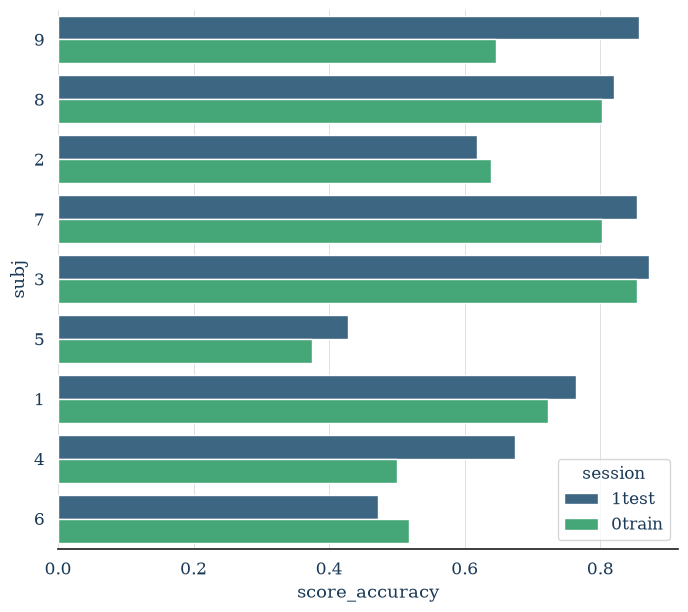

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()